# TASK 1 - Dataset Understanding + EDA


In this task, we:

- Load the "border_traffic_US_PL_01_03.csv" and inspect its structure.

- Check data quality (missing values, duplicates).

- Choose a classification target and verify class balance.

- Perform exploratory data analysis (EDA) using simple plots and short insights.

In [ ]:
import pandas as pd
import numpy as np


df = pd.read_csv("border_traffic_UA_PL_01_03.csv")

print("SHAPE (rows, cols):", df.shape)
print("\nCOLUMNS:")
print(df.columns.tolist())

print("\nFIRST 5 ROWS:")
display(df.head())

print("\nINFO:")
df.info()

print("\nMISSING VALUES (TOP):")
display(df.isna().sum().sort_values(ascending=False).head(15))

print("\nDUPLICATE ROWS:", df.duplicated().sum())


SHAPE (rows, cols): (54233, 10)

COLUMNS:
['Border Guard Post', 'Border crossing', 'Type of border crossing', 'Border Guard Unit', 'Date', 'Direction to / from Poland', 'Citizenship (code)', 'UE / Schengen', 'Number of persons (checked-in)', 'Number of people (evacuated)']

FIRST 5 ROWS:


,Border Guard Post,Border crossing,Type of border crossing,Border Guard Unit,Date,Direction to / from Poland,Citizenship (code),UE / Schengen,Number of persons (checked-in),Number of people (evacuated)
0,Dorohusk,Dorohusk-Jagodzin,road,Nadbuzanski,2022-01-01,arrival in Poland,BY,0,7,0
1,Dorohusk,Dorohusk-Jagodzin,road,Nadbuzanski,2022-01-01,arrival in Poland,DE,UE,29,0
2,Dorohusk,Dorohusk-Jagodzin,road,Nadbuzanski,2022-01-01,arrival in Poland,TR,0,2,0
3,Dorohusk,Dorohusk-Jagodzin,road,Nadbuzanski,2022-01-01,arrival in Poland,UA,0,389,0
4,Dorohusk,Dorohusk-Jagodzin,road,Nadbuzanski,2022-01-01,arrival in Poland,LV,UE,3,0



INFO:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 54233 entries, 0 to 54232
Data columns (total 10 columns):
 #   Column                          Non-Null Count  Dtype 
---  ------                          --------------  ----- 
 0   Border Guard Post               54233 non-null  object
 1   Border crossing                 54152 non-null  object
 2   Type of border crossing         54233 non-null  object
 3   Border Guard Unit               54233 non-null  object
 4   Date                            54233 non-null  object
 5   Direction to / from Poland      54233 non-null  object
 6   Citizenship (code)              54207 non-null  object
 7   UE / Schengen                   54233 non-null  object
 8   Number of persons (checked-in)  54233 non-null  int64 
 9   Number of people (evacuated)    54233 non-null  int64 
dtypes: int64(2), object(8)
memory usage: 4.1+ MB

MISSING VALUES (TOP):


,0
Border crossing,81
Citizenship (code),26
Border Guard Post,0
Type of border crossing,0
Date,0
Border Guard Unit,0
Direction to / from Poland,0
UE / Schengen,0
Number of persons (checked-in),0
Number of people (evacuated),0



DUPLICATE ROWS: 1270


## TASK 1 - Light Cleaning for EDA

In [3]:
df.columns = [c.strip() for c in df.columns]

# Try to detect a date column (common names)
possible_date_cols = [c for c in df.columns if "date" in c.lower() or "time" in c.lower() or "month" in c.lower()]

print("POSSIBLE DATE/TIME COLUMNS:", possible_date_cols)

# If there is a column that looks like a date, try parsing it
for c in possible_date_cols:
    try:
        df[c] = pd.to_datetime(df[c], errors="coerce")
    except:
        pass

# After parsing, show how many became NaT
for c in possible_date_cols:
    if np.issubdtype(df[c].dtype, np.datetime64):
        print(f"{c} parsed as datetime. NaT count:", df[c].isna().sum())


POSSIBLE DATE/TIME COLUMNS: ['Date']
Date parsed as datetime. NaT count: 0


## TASK 1 - Chose target (Classification)

Target selection (Classification)
For classification we need a categorical label. A good, clear target in this dataset is:

- Target (y): “Direction to / from Poland”
Because it is categorical (classes) and makes sense: we predict direction using crossing type, citizenship group, etc.

In [4]:
target_col = "Direction to / from Poland"

if target_col not in df.columns:
    print("ERROR: Target column not found. Available columns are:")
    print(df.columns.tolist())
else:
    print("TARGET COLUMN:", target_col)
    print("\nTARGET VALUE COUNTS:")
    display(df[target_col].value_counts(dropna=False))

    print("\nTARGET CLASS PROPORTIONS (%):")
    display((df[target_col].value_counts(normalize=True, dropna=False) * 100).round(2))


TARGET COLUMN: Direction to / from Poland

TARGET VALUE COUNTS:


,count
Direction to / from Poland,
arrival in Poland,41527
departure from Poland,12706



TARGET CLASS PROPORTIONS (%):


,proportion
Direction to / from Poland,
arrival in Poland,76.57
departure from Poland,23.43


## TASK 1 - EDA Plan

EDA plan (what we will visualize)
We will visualize:

- Target distribution (class counts)

- Counts by border crossing type

- Counts by citizenship and EU/Schengen group

- Numeric distribution (e.g., number of persons) and relationship with target

NUMERIC COLS: ['Number of persons (checked-in)', 'Number of people (evacuated)']
CATEGORICAL COLS (sample): ['Border Guard Post', 'Border crossing', 'Type of border crossing', 'Border Guard Unit', 'Direction to / from Poland', 'Citizenship (code)', 'UE / Schengen']


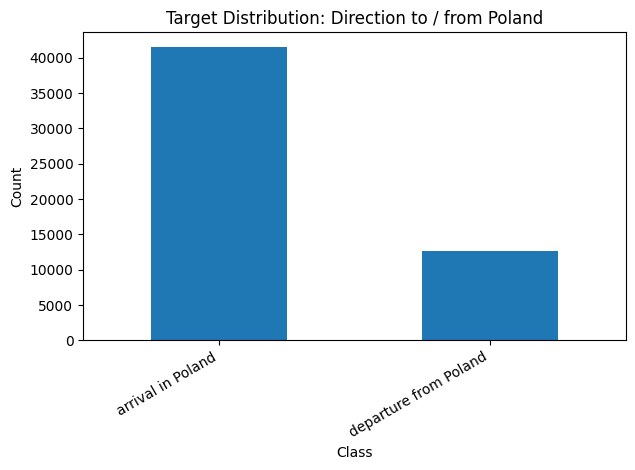

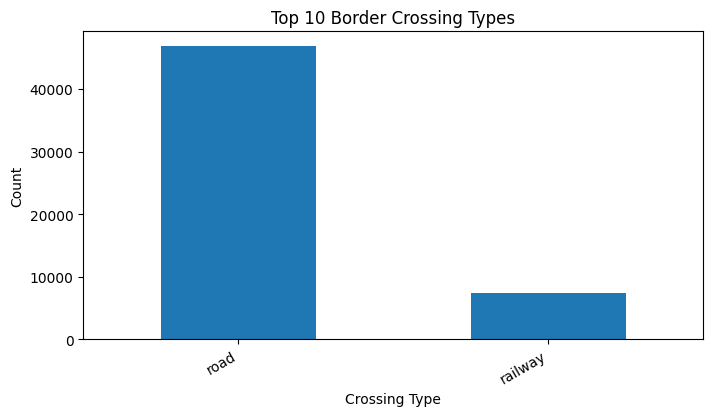

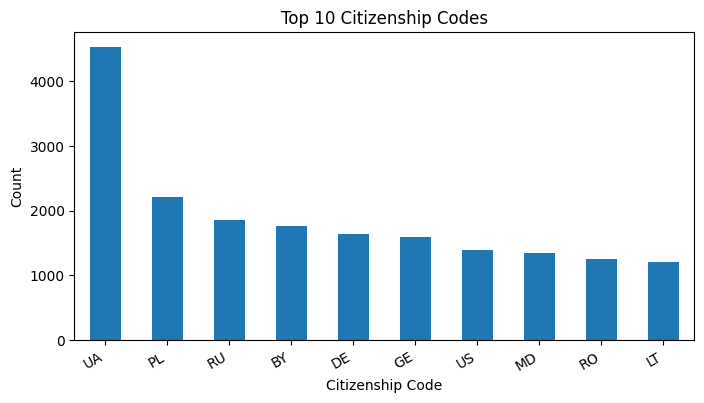

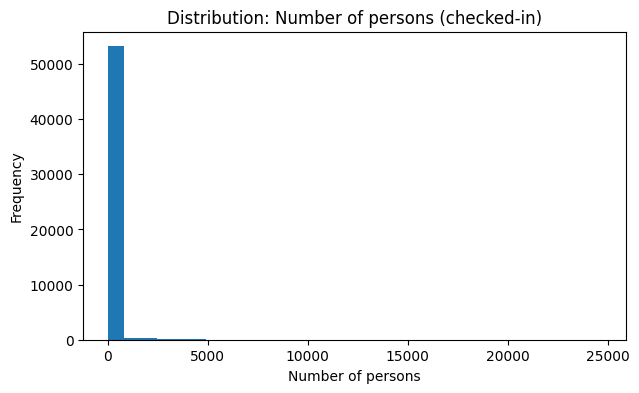

<Figure size 700x400 with 0 Axes>

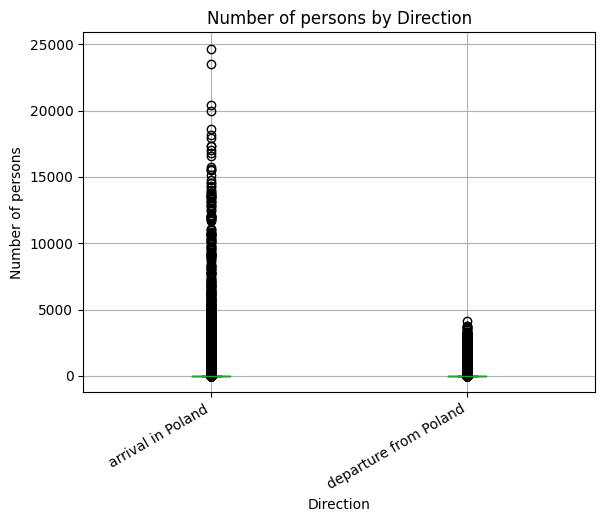

In [5]:
import matplotlib.pyplot as plt

# Helper: find numeric cols
numeric_cols = df.select_dtypes(include=["number"]).columns.tolist()
cat_cols = df.select_dtypes(include=["object", "category", "bool"]).columns.tolist()

print("NUMERIC COLS:", numeric_cols)
print("CATEGORICAL COLS (sample):", cat_cols[:10])

# 1) Target distribution
plt.figure(figsize=(7,4))
df[target_col].value_counts().plot(kind="bar")
plt.title("Target Distribution: Direction to / from Poland")
plt.xlabel("Class")
plt.ylabel("Count")
plt.xticks(rotation=30, ha="right")
plt.show()

# 2) Top categories for "Type of border crossing" (if exists)
crossing_col = "Type of border crossing"
if crossing_col in df.columns:
    plt.figure(figsize=(8,4))
    df[crossing_col].value_counts().head(10).plot(kind="bar")
    plt.title("Top 10 Border Crossing Types")
    plt.xlabel("Crossing Type")
    plt.ylabel("Count")
    plt.xticks(rotation=30, ha="right")
    plt.show()

# 3) Citizenship distribution (if exists)
cit_col = "Citizenship (code)"
if cit_col in df.columns:
    plt.figure(figsize=(8,4))
    df[cit_col].value_counts().head(10).plot(kind="bar")
    plt.title("Top 10 Citizenship Codes")
    plt.xlabel("Citizenship Code")
    plt.ylabel("Count")
    plt.xticks(rotation=30, ha="right")
    plt.show()

# 4) Numeric feature histogram (pick the most meaningful numeric column if it exists)
num_persons_col = "Number of persons (checked-in)"
if num_persons_col in df.columns:
    plt.figure(figsize=(7,4))
    df[num_persons_col].dropna().plot(kind="hist", bins=30)
    plt.title("Distribution: Number of persons (checked-in)")
    plt.xlabel("Number of persons")
    plt.ylabel("Frequency")
    plt.show()

    # Optional: compare numeric distribution by target class (simple boxplot)
    plt.figure(figsize=(7,4))
    df.boxplot(column=num_persons_col, by=target_col)
    plt.title("Number of persons by Direction")
    plt.suptitle("")
    plt.xlabel("Direction")
    plt.ylabel("Number of persons")
    plt.xticks(rotation=30, ha="right")
    plt.show()


## TASK 2 - Neural Network Classifier

- In this task, we:

- Define the target label (Direction to/from Poland).

- Prepare features (handle categorical + numeric + missing values).

- Split data into train/test to test generalization.

- Train an MLP (Neural Network) classifier.

- Evaluate using Accuracy, Precision, Recall, and F1-score.

In [7]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.neural_network import MLPClassifier

from sklearn.metrics import accuracy_score, precision_recall_fscore_support, classification_report, confusion_matrix

# Load dataset (use same path as Task 1)
df = pd.read_csv("border_traffic_UA_PL_01_03.csv")
df.columns = [c.strip() for c in df.columns]

target_col = "Direction to / from Poland"

# Drop rows where target is missing
df = df.dropna(subset=[target_col])

# X and y
X = df.drop(columns=[target_col])
y = df[target_col].astype(str)

# Identify columns
numeric_features = X.select_dtypes(include=["number"]).columns.tolist()
categorical_features = X.select_dtypes(include=["object", "category", "bool"]).columns.tolist()

print("Numeric features:", numeric_features)
print("Categorical features:", categorical_features[:10], "..." if len(categorical_features) > 10 else "")

# Train/test split (generalization)
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y  # keeps class proportions consistent
)

print("Train size:", X_train.shape, "Test size:", X_test.shape)


Numeric features: ['Number of persons (checked-in)', 'Number of people (evacuated)']
Categorical features: ['Border Guard Post', 'Border crossing', 'Type of border crossing', 'Border Guard Unit', 'Date', 'Citizenship (code)', 'UE / Schengen'] 
Train size: (43386, 9) Test size: (10847, 9)


## TASK 2 - Preprocessiong pipelline (missing values + encoding)

In [8]:
numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

preprocess = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features)
    ],
    remainder="drop"
)

print("Preprocessing pipeline ready.")


Preprocessing pipeline ready.


## TASK 2 - Train MLPClassifier + Evaluate

In [9]:
mlp_model = Pipeline(steps=[
    ("preprocess", preprocess),
    ("model", MLPClassifier(
        hidden_layer_sizes=(64, 32),   # 2 hidden layers
        activation="relu",
        solver="adam",
        max_iter=400,
        random_state=42
    ))
])

mlp_model.fit(X_train, y_train)

pred_train = mlp_model.predict(X_train)
pred_test  = mlp_model.predict(X_test)

# Metrics
train_acc = accuracy_score(y_train, pred_train)
test_acc  = accuracy_score(y_test, pred_test)

prec, rec, f1, _ = precision_recall_fscore_support(y_test, pred_test, average="weighted")

print("NEURAL NETWORK (MLPClassifier)")
print("Train Accuracy:", round(train_acc, 4))
print("Test Accuracy :", round(test_acc, 4))
print("Precision (weighted):", round(prec, 4))
print("Recall (weighted)   :", round(rec, 4))
print("F1-score (weighted) :", round(f1, 4))

print("\nClassification Report (Test):")
print(classification_report(y_test, pred_test))

print("\nConfusion Matrix (Test):")
print(confusion_matrix(y_test, pred_test))


NEURAL NETWORK (MLPClassifier)
Train Accuracy: 0.8546
Test Accuracy : 0.6409
Precision (weighted): 0.6421
Recall (weighted)   : 0.6409
F1-score (weighted) : 0.6415

Classification Report (Test):
                       precision    recall  f1-score   support

    arrival in Poland       0.77      0.76      0.77      8306
departure from Poland       0.24      0.24      0.24      2541

             accuracy                           0.64     10847
            macro avg       0.50      0.50      0.50     10847
         weighted avg       0.64      0.64      0.64     10847


Confusion Matrix (Test):
[[6346 1960]
 [1935  606]]


## TASK 3 - Two ML Models

In this task, we:

- Use the same train/test split and preprocessing.

- Train two classical classification models:

- Logistic Regression

- Random Forest

- Evaluate both using Accuracy, Precision, Recall, and F1-score.

- Compare results to decide which model performs better before tuning.

In [11]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer

from sklearn.metrics import accuracy_score, precision_recall_fscore_support, classification_report

df = pd.read_csv("border_traffic_UA_PL_01_03.csv")
df.columns = [c.strip() for c in df.columns]

target_col = "Direction to / from Poland"
df = df.dropna(subset=[target_col])

X = df.drop(columns=[target_col])
y = df[target_col].astype(str)

numeric_features = X.select_dtypes(include=["number"]).columns.tolist()
categorical_features = X.select_dtypes(include=["object", "category", "bool"]).columns.tolist()

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

preprocess = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features),
    ],
    remainder="drop"
)

print("Train:", X_train.shape, "Test:", X_test.shape)
print("Numeric features:", len(numeric_features), "Categorical features:", len(categorical_features))


Train: (43386, 9) Test: (10847, 9)
Numeric features: 2 Categorical features: 7


## TASK 3 -  Training Logistic Regression + Evaluate

In [12]:
from sklearn.linear_model import LogisticRegression

logreg = Pipeline(steps=[
    ("preprocess", preprocess),
    ("model", LogisticRegression(max_iter=2000, random_state=42))
])

logreg.fit(X_train, y_train)
pred_logreg = logreg.predict(X_test)

acc = accuracy_score(y_test, pred_logreg)
prec, rec, f1, _ = precision_recall_fscore_support(y_test, pred_logreg, average="weighted")

print("LOGISTIC REGRESSION (Test)")
print("Accuracy :", round(acc, 4))
print("Precision:", round(prec, 4))
print("Recall   :", round(rec, 4))
print("F1-score :", round(f1, 4))

print("\nClassification Report (Test):")
print(classification_report(y_test, pred_logreg))


LOGISTIC REGRESSION (Test)
Accuracy : 0.7549
Precision: 0.6998
Recall   : 0.7549
F1-score : 0.7049

Classification Report (Test):
                       precision    recall  f1-score   support

    arrival in Poland       0.78      0.94      0.85      8306
departure from Poland       0.43      0.14      0.21      2541

             accuracy                           0.75     10847
            macro avg       0.61      0.54      0.53     10847
         weighted avg       0.70      0.75      0.70     10847



## TASK 3 - Train Random Forest + Evaluate

In [13]:
from sklearn.ensemble import RandomForestClassifier

rf = Pipeline(steps=[
    ("preprocess", preprocess),
    ("model", RandomForestClassifier(
        n_estimators=200,
        random_state=42,
        n_jobs=-1
    ))
])

rf.fit(X_train, y_train)
pred_rf = rf.predict(X_test)

acc = accuracy_score(y_test, pred_rf)
prec, rec, f1, _ = precision_recall_fscore_support(y_test, pred_rf, average="weighted")

print("RANDOM FOREST (Test)")
print("Accuracy :", round(acc, 4))
print("Precision:", round(prec, 4))
print("Recall   :", round(rec, 4))
print("F1-score :", round(f1, 4))

print("\nClassification Report (Test):")
print(classification_report(y_test, pred_rf))


RANDOM FOREST (Test)
Accuracy : 0.6702
Precision: 0.6512
Recall   : 0.6702
F1-score : 0.66

Classification Report (Test):
                       precision    recall  f1-score   support

    arrival in Poland       0.77      0.81      0.79      8306
departure from Poland       0.26      0.22      0.24      2541

             accuracy                           0.67     10847
            macro avg       0.51      0.51      0.51     10847
         weighted avg       0.65      0.67      0.66     10847



## TASKK 3 - Quick comparision table

In [14]:
from sklearn.metrics import accuracy_score, precision_recall_fscore_support

def eval_clf(name, y_true, y_pred):
    acc = accuracy_score(y_true, y_pred)
    prec, rec, f1, _ = precision_recall_fscore_support(y_true, y_pred, average="weighted")
    return {"Model": name, "Accuracy": acc, "Precision": prec, "Recall": rec, "F1": f1}

results = []
results.append(eval_clf("Logistic Regression (Base)", y_test, pred_logreg))
results.append(eval_clf("Random Forest (Base)", y_test, pred_rf))

comparison_df = pd.DataFrame(results)
display(comparison_df)


,Model,Accuracy,Precision,Recall,F1
0,Logistic Regression (Base),0.754863,0.699848,0.754863,0.704873
1,Random Forest (Base),0.670231,0.651244,0.670231,0.659993


## TASK 4 - Hyperparameter Tuning + CV

In this task, we:

- Tune the hyperparameters of both classical models (Logistic Regression and Random Forest).

- Use cross-validation to estimate generalization performance.

- Report best hyperparameters and best cross-validation score.

- Re-train the best model on training data and evaluate on the test set.

In [16]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import accuracy_score, precision_recall_fscore_support

# Load dataset
df = pd.read_csv("border_traffic_UA_PL_01_03.csv")
df.columns = [c.strip() for c in df.columns]

target_col = "Direction to / from Poland"
df = df.dropna(subset=[target_col])

X = df.drop(columns=[target_col])
y = df[target_col].astype(str)

# Identify feature types
numeric_features = X.select_dtypes(include=["number"]).columns.tolist()
categorical_features = X.select_dtypes(include=["object", "category", "bool"]).columns.tolist()

# Split data
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# Preprocessing
numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

preprocess = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features),
    ],
    remainder="drop"
)

# Cross-validation strategy
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

print("Train:", X_train.shape, "Test:", X_test.shape)
print("CV folds:", cv.get_n_splits())


Train: (43386, 9) Test: (10847, 9)
CV folds: 5


## TASK 4 — Code Cell 2: GridSearchCV for Logistic Regression


In [17]:
logreg_pipe = Pipeline(steps=[
    ("preprocess", preprocess),
    ("model", LogisticRegression(max_iter=3000, random_state=42))
])

logreg_params = {
    "model__C": [0.01, 0.1, 1, 10],
    "model__penalty": ["l2"],
    "model__solver": ["lbfgs"],
}

logreg_grid = GridSearchCV(
    estimator=logreg_pipe,
    param_grid=logreg_params,
    cv=cv,
    scoring="f1_weighted",   # good when classes are imbalanced
    n_jobs=-1
)

logreg_grid.fit(X_train, y_train)

print("BEST Logistic Regression Params:", logreg_grid.best_params_)
print("BEST Logistic Regression CV (F1_weighted):", round(logreg_grid.best_score_, 4))


BEST Logistic Regression Params: {'model__C': 10, 'model__penalty': 'l2', 'model__solver': 'lbfgs'}
BEST Logistic Regression CV (F1_weighted): 0.7174


## TASK 4 — Code Cell 3: GridSearchCV for Random Forest

In [19]:
from sklearn.model_selection import GridSearchCV, StratifiedKFold
from sklearn.ensemble import RandomForestClassifier
from sklearn.pipeline import Pipeline

cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)  # reduced folds for speed

rf_pipe = Pipeline(steps=[
    ("preprocess", preprocess),
    ("model", RandomForestClassifier(random_state=42))
])

# Smaller grid (much faster)
rf_params = {
    "model__n_estimators": [100, 200],
    "model__max_depth": [None, 20],
    "model__min_samples_split": [2, 5],
    "model__min_samples_leaf": [1, 2],
}

rf_grid = GridSearchCV(
    estimator=rf_pipe,
    param_grid=rf_params,
    cv=cv,
    scoring="f1_weighted",
    n_jobs=1,          # IMPORTANT: avoids Colab worker crashes
    verbose=1
)

rf_grid.fit(X_train, y_train)

print("BEST Random Forest Params:", rf_grid.best_params_)
print("BEST Random Forest CV (F1_weighted):", round(rf_grid.best_score_, 4))


Fitting 3 folds for each of 16 candidates, totalling 48 fits
BEST Random Forest Params: {'model__max_depth': None, 'model__min_samples_leaf': 2, 'model__min_samples_split': 5, 'model__n_estimators': 100}
BEST Random Forest CV (F1_weighted): 0.722


## TASK 4 — Code Cell 4: Evaluate best tuned models on test set

In [20]:
def eval_model(name, model, X_test, y_test):
    pred = model.predict(X_test)
    acc = accuracy_score(y_test, pred)
    prec, rec, f1, _ = precision_recall_fscore_support(y_test, pred, average="weighted")
    return {"Model": name, "Accuracy": acc, "Precision": prec, "Recall": rec, "F1": f1}

best_logreg = logreg_grid.best_estimator_
best_rf     = rf_grid.best_estimator_

res_logreg = eval_model("Logistic Regression (Tuned)", best_logreg, X_test, y_test)
res_rf     = eval_model("Random Forest (Tuned)", best_rf, X_test, y_test)

tuned_compare = pd.DataFrame([res_logreg, res_rf])
display(tuned_compare)


,Model,Accuracy,Precision,Recall,F1
0,Logistic Regression (Tuned),0.756338,0.705860,0.756338,0.710654
1,Random Forest (Tuned),0.739836,0.697242,0.739836,0.709198


## TASK 5: Feature Selection
In this task, we:

- Apply a feature selection method to reduce the number of input features.

- Use SelectKBest (mutual information) to keep the most informative features.

- Train both classical models again using only the selected features.

- Compare performance before vs after feature selection.

In [22]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, MinMaxScaler
from sklearn.impute import SimpleImputer
from sklearn.feature_selection import SelectKBest, mutual_info_classif

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_recall_fscore_support

# Load dataset
df = pd.read_csv("border_traffic_UA_PL_01_03.csv")
df.columns = [c.strip() for c in df.columns]

target_col = "Direction to / from Poland"
df = df.dropna(subset=[target_col])

X = df.drop(columns=[target_col])
y = df[target_col].astype(str)

numeric_features = X.select_dtypes(include=["number"]).columns.tolist()
categorical_features = X.select_dtypes(include=["object", "category", "bool"]).columns.tolist()

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Preprocessing (good for feature selection)
numeric_transformer_fs = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", MinMaxScaler())
])

categorical_transformer_fs = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

preprocess_fs = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer_fs, numeric_features),
        ("cat", categorical_transformer_fs, categorical_features)
    ],
    remainder="drop"
)

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

print("Train:", X_train.shape, "Test:", X_test.shape)
print("Numeric:", len(numeric_features), "Categorical:", len(categorical_features))


Train: (43386, 9) Test: (10847, 9)
Numeric: 2 Categorical: 7


## TASK 5 — Code Cell 2: Choose best K (CV) using Logistic Regression

In [23]:
k_candidates = [10, 20, 40, 60]  # small list for speed (we can adjust if needed)

k_scores = []
for k in k_candidates:
    pipe = Pipeline(steps=[
        ("preprocess", preprocess_fs),
        ("select", SelectKBest(score_func=mutual_info_classif, k=k)),
        ("model", LogisticRegression(max_iter=3000, random_state=42))
    ])

    scores = cross_val_score(pipe, X_train, y_train, cv=cv, scoring="f1_weighted", n_jobs=-1)
    k_scores.append((k, scores.mean()))
    print(f"K={k} -> CV F1_weighted mean: {scores.mean():.4f}")

best_k = sorted(k_scores, key=lambda x: x[1], reverse=True)[0][0]
print("\nBEST K SELECTED:", best_k)


K=10 -> CV F1_weighted mean: 0.6657
K=20 -> CV F1_weighted mean: 0.6680
K=40 -> CV F1_weighted mean: 0.6726
K=60 -> CV F1_weighted mean: 0.6803

BEST K SELECTED: 60


TASK 5 — Code Cell 3: Train both models with selected features + evaluate on test

In [24]:
def eval_clf(name, model, X_test, y_test):
    pred = model.predict(X_test)
    acc = accuracy_score(y_test, pred)
    prec, rec, f1, _ = precision_recall_fscore_support(y_test, pred, average="weighted")
    return {"Model": name, "Accuracy": acc, "Precision": prec, "Recall": rec, "F1": f1}

# Logistic Regression + Feature Selection
logreg_fs = Pipeline(steps=[
    ("preprocess", preprocess_fs),
    ("select", SelectKBest(score_func=mutual_info_classif, k=best_k)),
    ("model", LogisticRegression(max_iter=3000, random_state=42))
])

# Random Forest + Feature Selection
rf_fs = Pipeline(steps=[
    ("preprocess", preprocess_fs),
    ("select", SelectKBest(score_func=mutual_info_classif, k=best_k)),
    ("model", RandomForestClassifier(
        n_estimators=200,
        random_state=42,
        n_jobs=-1
    ))
])

logreg_fs.fit(X_train, y_train)
rf_fs.fit(X_train, y_train)

res_logreg_fs = eval_clf("Logistic Regression + FS", logreg_fs, X_test, y_test)
res_rf_fs     = eval_clf("Random Forest + FS", rf_fs, X_test, y_test)

fs_compare = pd.DataFrame([res_logreg_fs, res_rf_fs])
display(fs_compare)


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/cluster/_supervised.py:59: UserWarning: Clustering metrics expects discrete values but received continuous values for label, and binary values for target
  warnings.warn(msg, UserWarning)
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/cluster/_supervised.py:59: UserWarning: Clustering metrics expects discrete values but received continuous values for label, and binary values for target
  warnings.warn(msg, UserWarning)
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/cluster/_supervised.py:59: UserWarning: Clustering metrics expects discrete values but received continuous values for label, and binary values for target
  warnings.warn(msg, UserWarning)
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/cluster/_supervised.py:59: UserWarning: Clustering metrics expects discrete values but received continuous values for label, and binary values for target
  warnings.warn(msg, UserWarning)


,Model,Accuracy,Precision,Recall,F1
0,Logistic Regression + FS,0.761685,0.682941,0.761685,0.676272
1,Random Forest + FS,0.755047,0.718490,0.755047,0.726647


## TASK 6: Final Tuned Models + Feature Selection + Comparison Table
In this task, we:

- Build the final Logistic Regression and Random Forest models using:

- best hyperparameters found in Task 4 (GridSearchCV)

- best selected features found in Task 5 (SelectKBest)

- Evaluate final models on the test set.

- Present results in a final comparison table (Accuracy, Precision, Recall, F1).

- This table is used directly in the final report.

In [29]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, MinMaxScaler
from sklearn.impute import SimpleImputer
from sklearn.feature_selection import SelectKBest, mutual_info_classif

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_recall_fscore_support

# ---- Load & split (same as before) ----
df = pd.read_csv("border_traffic_UA_PL_01_03.csv")
df.columns = [c.strip() for c in df.columns]

target_col = "Direction to / from Poland"
df = df.dropna(subset=[target_col])

X = df.drop(columns=[target_col])
y = df[target_col].astype(str)

numeric_features = X.select_dtypes(include=["number"]).columns.tolist()
categorical_features = X.select_dtypes(include=["object", "category", "bool"]).columns.tolist()

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# ---- Preprocess (same as FS stage) ----
numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", MinMaxScaler())
])

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

preprocess = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features),
    ],
    remainder="drop"
)

# IMPORTANT: set your best_k from Task 5
best_k = best_k if "best_k" in globals() else 40
print("Using best_k =", best_k)

# Best Params
best_logreg_params = {"model__C": 1.0}   # fallback
best_rf_params = {                      # fallback
    "model__n_estimators": 200,
    "model__max_depth": None,
    "model__min_samples_split": 2,
    "model__min_samples_leaf": 1
}

# If GridSearch completed, overwrite fallbacks
if "logreg_grid" in globals() and hasattr(logreg_grid, "best_params_"):
    best_logreg_params = logreg_grid.best_params_

if "rf_grid" in globals() and hasattr(rf_grid, "best_params_"):
    best_rf_params = rf_grid.best_params_

print("Using Logistic params:", best_logreg_params)
print("Using RF params:", best_rf_params)


# ---- Final models (tuned + FS) ----
final_logreg = Pipeline(steps=[
    ("preprocess", preprocess),
    ("select", SelectKBest(score_func=mutual_info_classif, k=best_k)),
    ("model", LogisticRegression(
        max_iter=3000,
        random_state=42,
        C=best_logreg_params["model__C"]
    ))
])

final_rf = Pipeline(steps=[
    ("preprocess", preprocess),
    ("select", SelectKBest(score_func=mutual_info_classif, k=best_k)),
    ("model", RandomForestClassifier(
        random_state=42,
        n_jobs=1,  # keep stable
        n_estimators=best_rf_params["model__n_estimators"],
        max_depth=best_rf_params["model__max_depth"],
        min_samples_split=best_rf_params["model__min_samples_split"],
        min_samples_leaf=best_rf_params["model__min_samples_leaf"],
    ))
])

final_logreg.fit(X_train, y_train)
final_rf.fit(X_train, y_train)

def eval_final(name, model):
    pred = model.predict(X_test)
    acc = accuracy_score(y_test, pred)
    prec, rec, f1, _ = precision_recall_fscore_support(y_test, pred, average="weighted")
    return {"Model": name, "K": best_k, "Accuracy": acc, "Precision": prec, "Recall": rec, "F1": f1}

final_table = pd.DataFrame([
    eval_final("FINAL Logistic Regression (Tuned + FS)", final_logreg),
    eval_final("FINAL Random Forest (Tuned + FS)", final_rf),
])

display(final_table)


Using best_k = 60
Using Logistic params: {'model__C': 10, 'model__penalty': 'l2', 'model__solver': 'lbfgs'}
Using RF params: {'model__n_estimators': 200, 'model__max_depth': None, 'model__min_samples_split': 2, 'model__min_samples_leaf': 1}


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/cluster/_supervised.py:59: UserWarning: Clustering metrics expects discrete values but received continuous values for label, and binary values for target
  warnings.warn(msg, UserWarning)
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/cluster/_supervised.py:59: UserWarning: Clustering metrics expects discrete values but received continuous values for label, and binary values for target
  warnings.warn(msg, UserWarning)
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/cluster/_supervised.py:59: UserWarning: Clustering metrics expects discrete values but received continuous values for label, and binary values for target
  warnings.warn(msg, UserWarning)
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/cluster/_supervised.py:59: UserWarning: Clustering metrics expects discrete values but received continuous values for label, and binary values for target
  warnings.warn(msg, UserWarning)


,Model,K,Accuracy,Precision,Recall,F1
0,FINAL Logistic Regression (Tuned + FS),60,0.761962,0.686081,0.761962,0.677601
1,FINAL Random Forest (Tuned + FS),60,0.755047,0.718490,0.755047,0.726647


## TASK 6 — Code Cell 2: Use Feature Selection K (from Task 5) + build FINAL models

In [31]:
from sklearn.model_selection import GridSearchCV, StratifiedKFold
from sklearn.ensemble import RandomForestClassifier
from sklearn.pipeline import Pipeline

cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)

rf_pipe = Pipeline(steps=[
    ("preprocess", preprocess),
    ("model", RandomForestClassifier(random_state=42))
])

rf_params = {
    "model__n_estimators": [100, 200],
    "model__max_depth": [None, 20],
    "model__min_samples_split": [2, 5],
    "model__min_samples_leaf": [1, 2]
}

rf_grid = GridSearchCV(
    rf_pipe, rf_params,
    cv=cv,
    scoring="f1_weighted",
    n_jobs=1,   # prevents joblib worker crash
    verbose=1
)

rf_grid.fit(X_train, y_train)

print("BEST RF Params:", rf_grid.best_params_)
print("BEST RF CV:", round(rf_grid.best_score_, 4))


Fitting 3 folds for each of 16 candidates, totalling 48 fits
BEST RF Params: {'model__max_depth': None, 'model__min_samples_leaf': 2, 'model__min_samples_split': 5, 'model__n_estimators': 100}
BEST RF CV: 0.7221


In [32]:
best_k = 60  #Best K found in Task 5

# Final Logistic Regression (tuned + FS)
final_logreg = Pipeline(steps=[
    ("preprocess", preprocess),
    ("select", SelectKBest(score_func=mutual_info_classif, k=best_k)),
    ("model", LogisticRegression(
        max_iter=3000,
        random_state=42,
        C=logreg_grid.best_params_["model__C"],
        penalty=logreg_grid.best_params_["model__penalty"],
        solver=logreg_grid.best_params_["model__solver"]
    ))
])

# Final Random Forest (tuned + FS)
final_rf = Pipeline(steps=[
    ("preprocess", preprocess),
    ("select", SelectKBest(score_func=mutual_info_classif, k=best_k)),
    ("model", RandomForestClassifier(
        random_state=42,
        n_jobs=-1,
        n_estimators=rf_grid.best_params_["model__n_estimators"],
        max_depth=rf_grid.best_params_["model__max_depth"],
        min_samples_split=rf_grid.best_params_["model__min_samples_split"],
        min_samples_leaf=rf_grid.best_params_["model__min_samples_leaf"]
    ))
])

final_logreg.fit(X_train, y_train)
final_rf.fit(X_train, y_train)

print("Final models trained with tuned params + feature selection.")


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/cluster/_supervised.py:59: UserWarning: Clustering metrics expects discrete values but received continuous values for label, and binary values for target
  warnings.warn(msg, UserWarning)
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/cluster/_supervised.py:59: UserWarning: Clustering metrics expects discrete values but received continuous values for label, and binary values for target
  warnings.warn(msg, UserWarning)
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/cluster/_supervised.py:59: UserWarning: Clustering metrics expects discrete values but received continuous values for label, and binary values for target
  warnings.warn(msg, UserWarning)
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/cluster/_supervised.py:59: UserWarning: Clustering metrics expects discrete values but received continuous values for label, and binary values for target
  warnings.warn(msg, UserWarning)


Final models trained with tuned params + feature selection.


## TASK 6 — Code Cell 3: Evaluate FINAL models + Final Comparison Table

In [33]:
from sklearn.metrics import accuracy_score, precision_recall_fscore_support

def eval_final(name, model, X_test, y_test):
    pred = model.predict(X_test)
    acc = accuracy_score(y_test, pred)
    prec, rec, f1, _ = precision_recall_fscore_support(y_test, pred, average="weighted")
    return {"Model": name, "Selected_Features(K)": best_k, "Accuracy": acc, "Precision": prec, "Recall": rec, "F1": f1}

final_res_logreg = eval_final("FINAL Logistic Regression (Tuned + FS)", final_logreg, X_test, y_test)
final_res_rf     = eval_final("FINAL Random Forest (Tuned + FS)", final_rf, X_test, y_test)

final_table = pd.DataFrame([final_res_logreg, final_res_rf])
display(final_table)


,Model,Selected_Features(K),Accuracy,Precision,Recall,F1
0,FINAL Logistic Regression (Tuned + FS),60,0.761962,0.686081,0.761962,0.677601
1,FINAL Random Forest (Tuned + FS),60,0.766664,0.725931,0.766664,0.726208
